In [1]:
import os
import random
import json
import pandas as pd
import torch
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
import matplotlib.pyplot as plt

In [2]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device

device(type='cuda', index=0)

In [3]:
dir_path = '/NasData/home/kmj/test/term/data'
dir_list = os.listdir(dir_path)

In [4]:
src = []
tgt = []

In [5]:
for js in dir_list:
    new = os.path.join(dir_path, js)
    with open (new, 'r') as f:
        json_data = json.load(f)
    
    for l in json_data['paragraph']:
        for text in l['sentences']:
            src.append(text['tgt_sentence'])
            tgt.append(text['src_sentence'])

    
    

In [25]:
r = random.randint(0,213688)
print(src[r])
print()
print(tgt[r])

As a result, relative to the past, neighboring powers' influence has also started to decline.

그 결과 주변 강대국들의 영향력도 과거보다 상대적으로 약해지기 시작했다.


In [7]:
dic = {'en' : src, 'ko' : tgt}
df = pd.DataFrame(dic)

In [8]:
pd.set_option('display.max_colwidth', 300)

In [9]:
df.head()

,en,ko
0,"There is a way to crack down on drugs by using machines like X-rays, but it is undeniable that drug detection dogs are excellent at sorting out drug items. .",X-ray 와 같은 기계로 마약류의 물품을 단속해내는 방법도 있지만 마약탐지견이 마약류 물품을 선별해내는 것에 탁월한 것은 틀림없는 사실이다.
1,"By examining the status of overseas direct purchases through past research and assessing the government's customs clearance system, this study aimed to compare and analyze customs procedures in other countries.",선행연구를 통한 해외직접구매 현황파악과 이와 관련된 정부의 통관제도 분석을 통해 해외 국가 통관절차를 비교 분석하고자 하였다.
2,"The analysis shows that the types of declaration of express items carried into Korea by express businesses may be split into inventory customs clearing, simplified import declaration, and general import declaration, in accordance with the simplified customs clearance procedure in Korea.","분석결과, 우리나라 간이통관 절차상 특송업체가 우리나라에 반입하는 특송물품의 신고유형은 목록통관, 간이수입신고, 일반수입신고로 구분할 수 있다."
3,The express firm presents the customs list to the head of the customs office and omits the import declaration for items for personal use or duty-free commercial samples with a price of less than USD 150 at the time of import declaration for simple customs clearance and the exemption of duties an...,"수입신고 당시 물품 가격이 미화 150달러 이하면서 본인이 사용할 자가사용 물품이거나 면세되는 상용견품의 경우 특송업체가 세관장에게 통관목록 제출하고, 수입신고 생략하면서 관세 및 부가세가 면제되어 간단히 통관한다."
4,Consumers who yearn for new products and services use these duty-free benefits to import various overseas direct purchases.,새로운 제품과 서비스 등을 갈구하는 소비자들은 이러한 면세 혜택을 이용하여 다양한 해외직구물품을 반입하고 있다.


In [10]:
df.to_csv('en2ko.csv')

In [11]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 213688 entries, 0 to 213687
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   en      213688 non-null  object
 1   ko      213688 non-null  object
dtypes: object(2)
memory usage: 3.3+ MB
None


In [12]:
df.isnull().sum()

en    0
ko    0
dtype: int64

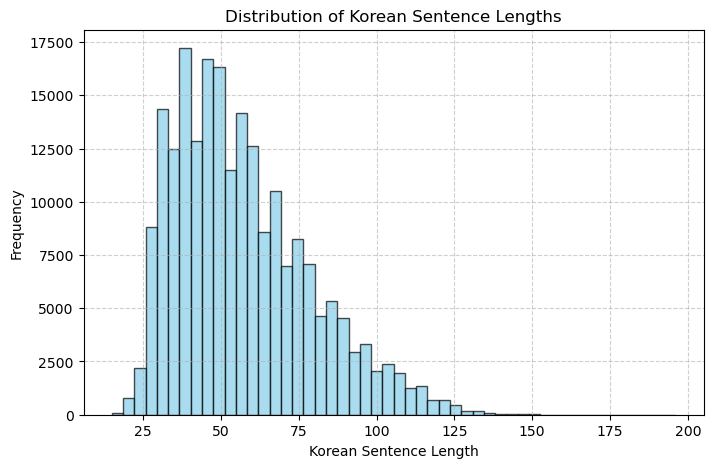

In [19]:
lengths = df['ko'].str.len()

plt.figure(figsize=(8,5))
plt.hist(lengths, bins=50, color='skyblue', edgecolor='black', alpha=0.7)  # bin 수 늘리고 색상 지정
plt.xlabel('Korean Sentence Length')
plt.ylabel('Frequency')
plt.title('Distribution of Korean Sentence Lengths')
plt.grid(True, linestyle='--', alpha=0.6)  # 점선 그리드로 깔끔하게
plt.show()

In [14]:
def str_len(df, cate):
    r0_50 = 0
    r50_100 = 0
    r100_150 = 0
    r150_200 = 0
    r200_250 = 0
    r250_300 = 0
    r300_350 = 0
    r350_400 = 0
    r400_ = 0

    max_len = 0

    for i in df[cate]:
        if len(i) < 50:
            r0_50 += 1
        elif len(i) < 100:
            r50_100 += 1
        elif len(i) < 150:
            r100_150 += 1
        elif len(i) < 200:
            r150_200 += 1
        elif len(i) < 250:
            r200_250 += 1
        elif len(i) < 300:
            r250_300 += 1
        elif len(i) < 350:
            r300_350 += 1
        elif len(i) < 400:
            r350_400 += 1
        else:
            r400_ += 1
        
        if max_len < len(i):
            max_len = len(i)
    
    if cate == 'en':
        ca = 'English'
    if cate == 'ko':
        ca = 'Korean'
    

    
    print(ca)
    print(f'0-50 : {r0_50}개, 50-100 : {r50_100}개, 100-150 : {r100_150}개, 150-200 : {r150_200}개, 200-250 : {r200_250}개, 250-300 : {r250_300}개, 300-350 : {r300_350}개, 350-400 : {r350_400}개, 400- : {r400_}개')
    print('최대 길이 :',max_len)
    print()



In [15]:
str_len(df, 'en')
str_len(df, 'ko')

English
0-50 : 3787개, 50-100 : 70343개, 100-150 : 75177개, 150-200 : 39993개, 200-250 : 16792개, 250-300 : 5814개, 300-350 : 1473개, 350-400 : 249개, 400- : 60개
최대 길이 : 549

Korean
0-50 : 93777개, 50-100 : 109304개, 100-150 : 10583개, 150-200 : 24개, 200-250 : 0개, 250-300 : 0개, 300-350 : 0개, 350-400 : 0개, 400- : 0개
최대 길이 : 196



In [16]:
import re
from collections import Counter

def tokenize(text):
    return re.findall(r"[가-힣]+|[a-zA-Z]+|\d+", text)

with open("en2ko.txt", "r", encoding="utf-8") as f:
    lines = f.readlines()

words = []
for line in lines:
    words.extend(tokenize(line.strip()))

counter = Counter(words)

for word, freq in counter.most_common(50):
    print(word, freq)

print("고유 단어 수:", len(counter))

the 302850
of 154473
to 125221
and 124163
a 102845
in 91236
is 82687
that 64584
as 38801
it 37767
The 36690
was 34170
are 33854
수 33069
s 32927
for 30987
be 30192
있다 27972
on 26422
with 25975
by 25104
this 20999
from 19491
not 19280
이 18164
can 17882
or 17494
an 16808
have 15659
있는 15251
그 15119
것이다 14874
at 14647
which 14549
In 14145
were 13619
has 13277
It 12126
I 11917
will 11762
they 11754
but 11618
you 11204
when 11125
time 10872
their 10494
more 10362
if 10290
1 10165
other 10162
고유 단어 수: 459115


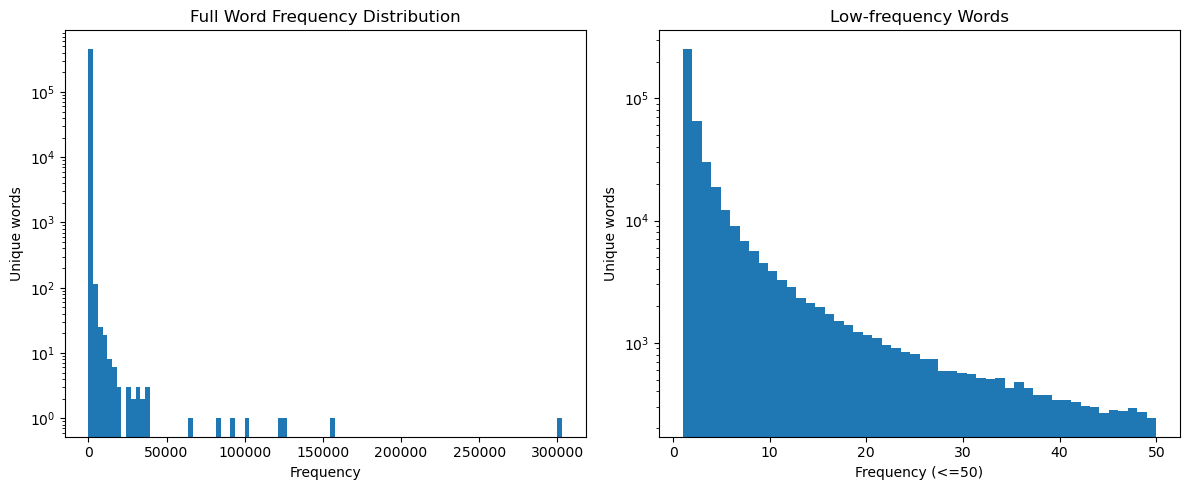

In [26]:
import numpy as np
freqs = np.array(list(counter.values()))

plt.figure(figsize=(12,5))

# (a) 전체 분포
plt.subplot(1,2,1)
plt.hist(freqs, bins=100, log=True)
plt.xlabel("Frequency")
plt.ylabel("Unique words")
plt.title("Full Word Frequency Distribution")

# (b) 초반부 확대 (예: freq <= 50)
plt.subplot(1,2,2)
plt.hist(freqs[freqs <= 50], bins=50, log=True)
plt.xlabel("Frequency (<=50)")
plt.ylabel("Unique words")
plt.title("Low-frequency Words")

plt.tight_layout()
plt.show()

In [27]:
total = sum(counter.values())
kept = sum(freq for freq in counter.values() if freq >= 5)
print(kept, total)
print("빈도 25 이상 단어가 차지하는 비율:", kept / total * 100, "%")

7092681 7640968
빈도 25 이상 단어가 차지하는 비율: 92.82437774899725 %


In [28]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
tokenizer = AutoTokenizer.from_pretrained("NHNDQ/nllb-finetuned-en2ko")
model = AutoModelForSeq2SeqLM.from_pretrained("NHNDQ/nllb-finetuned-en2ko")

In [31]:
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Trainable parameters:", trainable_params)

Trainable parameters: 615073792


In [32]:
import torch.nn as nn

In [36]:
model = nn.Transformer()
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Trainable parameters:", trainable_params)

Trainable parameters: 44140544
